In [2]:
import numpy as np
import torch as th
import time, json, sys, os
import argparse
from PIL import Image

parser = argparse.ArgumentParser()
# parser.add_argument('--set_', default='train')
# parser.add_argument('--sample_json', required=True)
# parser.add_argument('--rasterize_type', default='standard')
# parser.add_argument('--n_frames', type=int, required=True)
# args = parser.parse_args()

n_frames = 20
set_ = 'valid'
sample_json = '/home/mint/Dev/DiFaReli/difareli-faster/eval_request/sumit.json'
rasterize_type = 'standard'
import misc
deca_params, avg_dict = misc.load_deca_params(deca_dir=f'/data/mint/DPM_Dataset/eval_request/Sumit/params/{set_}', cfg=None)


Loading deca params...: 100%|██████████| 10/10 [00:00<00:00, 275.73it/s]


In [6]:
print(deca_params.keys())
print(deca_params['input.png'])

dict_keys(['input.png', 'output.png', '0.jpg'])
{'shadow': array([0.7272945]), 'shape': array([ 3.41657100e-01, -2.37980600e-02,  2.03395170e-01,  1.03541700e-01,
        2.52656200e-02,  3.95065620e-02,  3.15715760e-01,  3.93187460e-01,
       -3.58228100e-01,  9.49709000e-02,  1.45652890e-03,  4.44462750e-01,
        5.14005530e-02,  4.23308460e-03,  6.92676700e-02,  3.60584100e-02,
       -2.02980820e-01, -3.14498480e-01, -3.10078000e-02, -6.57854300e-01,
        2.48733970e-01,  3.10871540e-01, -2.59446860e-01,  2.73589280e-01,
       -1.94210650e-01, -5.13600700e-02, -1.55192970e-01, -5.18826900e-01,
        5.38908240e-01,  1.80978280e-01,  1.65756400e-01, -1.76367490e-01,
        1.00837690e-01, -1.24398210e-01, -2.69077840e-01, -1.97838050e-01,
       -2.47130200e-01, -5.20202460e-01, -1.42805220e-01, -3.28600400e-04,
       -3.11301600e-01,  2.48840270e-01, -5.00354800e-01, -6.48142800e-01,
        6.39614460e-01, -2.00491010e-01,  2.45751460e-01,  3.29155300e-01,
       -4.60

In [7]:
sys.path.append("/home/mint/Dev/DiFaReli/difareli-faster/sample_scripts/sample_utils/")
import mani_utils, params_utils
start_t = time.time()
mask = params_utils.load_flame_mask()
deca_obj = params_utils.init_deca(mask=mask, rasterize_type=rasterize_type)
print(f"[#] Time taken to load DECA: {time.time()-start_t}")

# with open(sample_json) as f:
#     gen_shadow = json.load(f)['pair']

# Load params

/home/mint/miniconda3/envs/dpm_sampling_deca_pysh/lib/python3.8/site-packages/torch/cuda/__init__.py:52: UserWarning: CUDA initialization: CUDA driver initialization failed, you might not have a CUDA gpu. (Triggered internally at  /opt/conda/conda-bld/pytorch_1603729096996/work/c10/cuda/CUDAFunctions.cpp:100.)
  return torch._C._cuda_getDeviceCount() > 0


creating the FLAME Decoder


RuntimeError: CUDA driver initialization failed, you might not have a CUDA gpu.

In [40]:
# Load the DeCA model
sj = '4085.jpg'
rotate_sh_axis = 2
n_step = n_frames
src_idx = 0
cond = deca_params[sj].copy()
render_batch_size = 20
render_mode = 'shape'
rotate_normals = False
# cond = {k: cond[k] for k in keys}
for k in cond.keys():
    cond[k] = th.tensor(cond[k][None, ...])
cond['raw_image_path'] = ['/data/mint/DPM_Dataset/ffhq_256_with_anno/ffhq_256/train/' + sj]
cond['raw_image'] = th.tensor(np.array(Image.open(cond['raw_image_path'][0]))).permute(2, 0, 1)[None, ...]

print(cond['light'].shape)
interp_cond = mani_utils.rotate_sh(cond, src_idx=src_idx, n_step=n_step, axis=rotate_sh_axis)
print(interp_cond['light'].shape)
sub_step = mani_utils.ext_sub_step(n_step, render_batch_size)
cond['light'] = interp_cond['light']

for i in range(len(sub_step)-1):
    start = sub_step[i]
    end = sub_step[i+1]
    sub_cond = cond.copy()
    sub_cond['light'] = sub_cond['light'][start:end, :]
    # Deca rendered : B x 3 x H x W
    deca_rendered, orig_visdict = params_utils.render_deca(deca_params=sub_cond, 
                                                        idx=0, n=end-start, 
                                                        avg_dict=avg_dict, 
                                                        render_mode=render_mode, 
                                                        rotate_normals=rotate_normals, 
                                                        mask=mask,
                                                        deca_obj=deca_obj,
                                                        repeat=True)
    

torch.Size([1, 27])
(20, 27)


/home/mint/Dev/DiFaReli/difareli-faster/sample_scripts/sample_utils/mani_utils.py:323: UserWarning: Gimbal lock detected. Setting third angle to zero since it is not possible to uniquely determine all angles.
  return rot.as_euler('zyz', degrees=True)


1 1


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

1.2391078
0.0


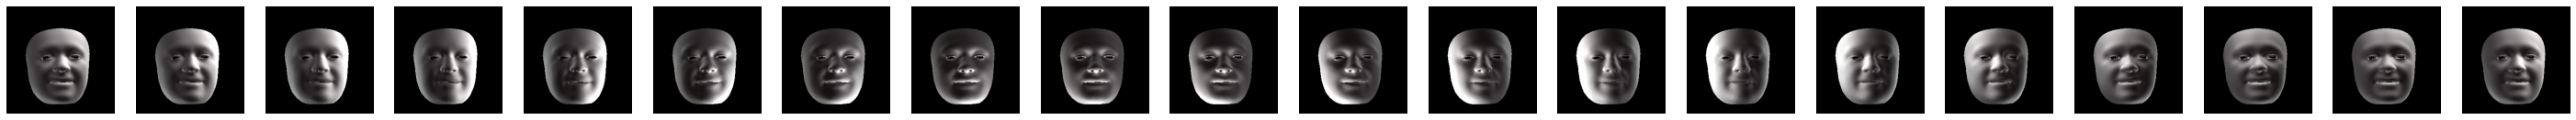

In [48]:
deca_rendered.shape
deca_rendered = deca_rendered#.cpu().numpy()
# Vis all images
import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, n_frames, figsize=(50, 50))
for i in range(n_frames):
    axs[i].imshow(deca_rendered[i].transpose(1, 2, 0))
    axs[i].axis('off')

# Save as video with torchvision
import torchvision.io as tvio
print(deca_rendered.max())
print(deca_rendered.min())
tvio.write_video('deca_rendered.mp4', np.clip(deca_rendered.transpose(0, 2, 3, 1) * 255, 0, 255), 30)
